# University Student Lifecycle Python POC

This notebook validates the core logic behind the University Student Lifecycle platform.

The proof of concept focuses on:
- University matching
- Course comparison
- Application deadline urgency
- Academic progress tracking
- Dashboard-style outputs using Python tables and charts

This is not the full product. The Figma shows the full system vision. This notebook proves that the core logic can work using Python.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

np.random.seed(42)

## 1. Synthetic University Data

The POC uses synthetic university data to test how the platform could compare schools across cost, location, employment outcomes, satisfaction, and ROI.

In [9]:
universities = pd.DataFrame({
    "university": ["UW Bothell", "Arizona State", "University of Oregon", "Northeastern", "Georgia State"],
    "tuition": [12000, 31000, 36000, 63000, 29000],
    "cost_of_living": [18000, 15000, 16000, 24000, 14000],
    "employment_rate": [0.84, 0.81, 0.78, 0.89, 0.76],
    "student_satisfaction": [4.2, 4.0, 3.8, 4.3, 3.7],
    "location_score": [8, 7, 7, 9, 6],
    "roi_score": [8.5, 7.4, 6.9, 8.2, 7.1]
})

universities

,university,tuition,cost_of_living,employment_rate,student_satisfaction,location_score,roi_score
0,UW Bothell,12000,18000,0.84,4.2,8,8.5
1,Arizona State,31000,15000,0.81,4.0,7,7.4
2,University of Oregon,36000,16000,0.78,3.8,7,6.9
3,Northeastern,63000,24000,0.89,4.3,9,8.2
4,Georgia State,29000,14000,0.76,3.7,6,7.1


## 2. Personalized University Matching Engine

This section tests the core matching logic. The model ranks universities using weighted factors that matter to students: employment outcomes, satisfaction, location, and ROI.

The point of the POC is to show that the platform can personalize rankings instead of showing one generic ranking list.

In [10]:
weights = {
    "employment_rate": 0.30,
    "student_satisfaction": 0.20,
    "location_score": 0.20,
    "roi_score": 0.30
}

ranked_universities = universities.copy()

ranked_universities["final_match_score"] = (
    ranked_universities["employment_rate"] * 100 * weights["employment_rate"] +
    ranked_universities["student_satisfaction"] * 20 * weights["student_satisfaction"] +
    ranked_universities["location_score"] * 10 * weights["location_score"] +
    ranked_universities["roi_score"] * 10 * weights["roi_score"]
)

ranked_universities = ranked_universities.sort_values(
    by="final_match_score",
    ascending=False
)

ranked_universities

,university,tuition,cost_of_living,employment_rate,student_satisfaction,location_score,roi_score,final_match_score
3,Northeastern,63000,24000,0.89,4.3,9,8.2,86.5
0,UW Bothell,12000,18000,0.84,4.2,8,8.5,83.5
1,Arizona State,31000,15000,0.81,4.0,7,7.4,76.5
2,University of Oregon,36000,16000,0.78,3.8,7,6.9,73.3
4,Georgia State,29000,14000,0.76,3.7,6,7.1,70.9


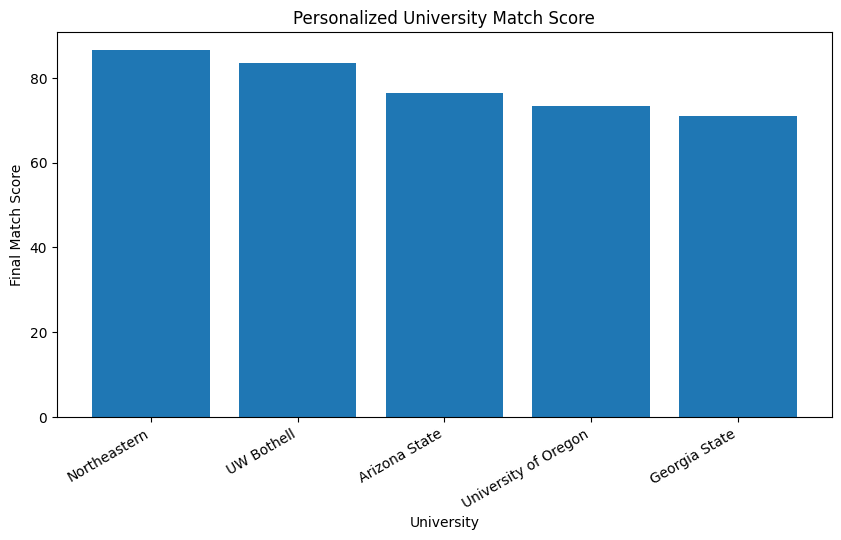

In [11]:
plt.figure(figsize=(10, 5))
plt.bar(ranked_universities["university"], ranked_universities["final_match_score"])
plt.title("Personalized University Match Score")
plt.xlabel("University")
plt.ylabel("Final Match Score")
plt.xticks(rotation=30, ha="right")
plt.show()

## 3. Course Comparison

This section shows how the platform could compare programs across tuition, salary outcomes, employment rate, and ROI. This supports the Phase I student decision process.

In [13]:
courses = pd.DataFrame({
    "program": ["Business Administration", "Information Systems", "Finance", "Marketing", "Computer Science"],
    "university": ["UW Bothell", "Arizona State", "Northeastern", "University of Oregon", "Georgia State"],
    "tuition": [12000, 31000, 63000, 36000, 29000],
    "average_starting_salary": [65000, 72000, 78000, 61000, 80000],
    "employment_rate": [0.84, 0.86, 0.89, 0.78, 0.82]
})

courses["salary_to_tuition_ratio"] = courses["average_starting_salary"] / courses["tuition"]

courses = courses.sort_values(
    by="salary_to_tuition_ratio",
    ascending=False
)

courses

,program,university,tuition,average_starting_salary,employment_rate,salary_to_tuition_ratio
0,Business Administration,UW Bothell,12000,65000,0.84,5.416667
4,Computer Science,Georgia State,29000,80000,0.82,2.758621
1,Information Systems,Arizona State,31000,72000,0.86,2.322581
3,Marketing,University of Oregon,36000,61000,0.78,1.694444
2,Finance,Northeastern,63000,78000,0.89,1.238095


## 4. Application Deadline Urgency Tracking

This section shows how the platform can help students track application deadlines and identify which applications need attention first.

In [14]:
applications = pd.DataFrame({
    "university": ["UW Bothell", "Arizona State", "Northeastern", "University of Oregon"],
    "program": ["Business Administration", "Information Systems", "Finance", "Marketing"],
    "deadline": pd.to_datetime(["2026-06-15", "2026-07-01", "2026-06-08", "2026-08-01"]),
    "status": ["Researching", "Applied", "Not Started", "Researching"]
})

today = pd.to_datetime("2026-06-07")
applications["days_until_deadline"] = (applications["deadline"] - today).dt.days

def urgency_label(days):
    if days <= 3:
        return "High urgency"
    elif days <= 14:
        return "Medium urgency"
    else:
        return "Low urgency"

applications["urgency"] = applications["days_until_deadline"].apply(urgency_label)

applications

,university,program,deadline,status,days_until_deadline,urgency
0,UW Bothell,Business Administration,2026-06-15,Researching,8,Medium urgency
1,Arizona State,Information Systems,2026-07-01,Applied,24,Low urgency
2,Northeastern,Finance,2026-06-08,Not Started,1,High urgency
3,University of Oregon,Marketing,2026-08-01,Researching,55,Low urgency


## 5. Academic Progress Dashboard

This section shows how the platform could support enrolled students by tracking grades, attendance, and academic risk level.

In [15]:
academic_progress = pd.DataFrame({
    "course": ["MIS Capstone", "Finance", "Business Communication", "Marketing"],
    "current_grade": [92, 87, 84, 90],
    "attendance_pct": [96, 90, 88, 94],
    "risk_level": ["Low", "Medium", "Medium", "Low"]
})

academic_progress

,course,current_grade,attendance_pct,risk_level
0,MIS Capstone,92,96,Low
1,Finance,87,90,Medium
2,Business Communication,84,88,Medium
3,Marketing,90,94,Low


## POC Summary

This Python POC validates the platform’s core logic using synthetic data.

The notebook demonstrates:
- A personalized university ranking engine
- A course and university comparison table
- Application deadline urgency tracking
- Academic progress dashboard outputs

The full product vision is shown in Figma, while this notebook proves that the main recommendation and tracking logic can be built in Python.